In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import os


In [26]:
all_merged_dir = "C:/Users/jiahan2/Desktop/ACE_592/Final_Project/"

# Load the parquet file that is a panel including EV WATTS, Weather
allMerged_df = pd.read_parquet(os.path.join(all_merged_dir, "merged_metro_day.parquet"))

# Preview the data
print(allMerged_df.shape)
print(allMerged_df.head())
print(allMerged_df.dtypes)

(8110862, 29)
   session_id  evse_id  connector_id       start_datetime  \
0       11564       72            72  2020-03-01 10:06:08   
1       11565        1             1  2020-03-01 10:01:12   
2       11566        0           138  2020-02-29 19:09:03   
3       11569       72           201  2020-03-01 08:43:22   
4       11570       14            14  2020-03-01 08:29:45   

          end_datetime  total_duration  charge_duration  energy_kwh  \
0  2020-03-01 11:08:10        1.033611         1.024722       3.392   
1  2020-03-01 11:07:09        1.099722         1.076111       6.521   
2  2020-03-01 10:47:16       15.636667        12.658889      80.527   
3  2020-03-01 10:09:41        1.438611         1.416389       8.949   
4  2020-03-01 09:56:48        1.451667         1.446667       4.238   

   start_soc  end_soc  ...  temperature_2m_max temperature_2m_min  \
0        NaN      NaN  ...                 5.0               -8.2   
1        NaN      NaN  ...                 2.5        

In [30]:
metro_ref = pd.read_excel("C:/Users/jiahan2/Desktop/ACE_592/Final_Project/Metro/usmetros.xlsx")

# ── Your 29 metro areas from allMerged_df ─────────────────────────────────────
metro_stats = allMerged_df.groupby("metro_area").agg(
    num_sessions        = ("session_id",      "count"),
    total_energy_kwh    = ("energy_kwh",      "sum"),
    avg_charge_duration = ("charge_duration", "mean"),
).reset_index()

# ── Clean keys for matching ───────────────────────────────────────────────────
def clean_key(name):
    return (name
            .replace(" Metro Area", "").replace(" metro area", "")
            .replace(" MSA", "")
            .strip()
            .lower())

metro_stats["metro_key"] = metro_stats["metro_area"].apply(clean_key)
metro_ref["metro_key"]   = metro_ref["metro_full"].apply(clean_key)

# ── Merge to get lat/lon ──────────────────────────────────────────────────────
# Deduplicate ref (one row per metro)
metro_ref_dedup = metro_ref[["metro_key", "lat", "lng"]].drop_duplicates("metro_key")

merged = metro_stats.merge(metro_ref_dedup, on="metro_key", how="left")

# ── Check match quality ───────────────────────────────────────────────────────
unmatched = merged[merged["lat"].isna()]["metro_area"].tolist()
print(f"Matched:   {merged['lat'].notna().sum()} / {len(merged)}")
print(f"Unmatched: {unmatched}")

Matched:   21 / 29
Unmatched: ['Austin-Round Rock-Georgetown, TX Metro Area', 'Chicago-Naperville-Elgin, IL-IN-WI Metro Area', 'Denver-Aurora-Lakewood, CO Metro Area', 'Grand Rapids-Kentwood, MI Metro Area', 'Las Vegas-Henderson-Paradise, NV Metro Area', 'Miami-Fort Lauderdale-Pompano Beach, FL Metro Area', 'New York-Newark-Jersey City, NY-NJ-PA Metro Area', 'Worcester, MA-CT Metro Area']


In [32]:
# ── Manual fixes for the 8 unmatched metros ───────────────────────────────────
manual_map = {
    # your metro_area key                          : metro_ref metro_key
    "austin-round rock-georgetown, tx":            "austin-round rock-san marcos, tx",
    "chicago-naperville-elgin, il-in-wi":          "chicago-naperville-elgin, il-in",
    "denver-aurora-lakewood, co":                  "denver-aurora-centennial, co",
    "grand rapids-kentwood, mi":                   "grand rapids-wyoming-kentwood, mi",
    "las vegas-henderson-paradise, nv":            "las vegas-henderson-north las vegas, nv",
    "miami-fort lauderdale-pompano beach, fl":     "miami-fort lauderdale-west palm beach, fl",
    "new york-newark-jersey city, ny-nj-pa":       "new york-newark-jersey city, ny-nj",
    "worcester, ma-ct":                            "worcester, ma",
}

# Apply manual map before merging
metro_stats["metro_key_matched"] = metro_stats["metro_key"].apply(
    lambda k: manual_map.get(k, k)
)

# ── Merge using corrected keys ────────────────────────────────────────────────
merged = metro_stats.merge(
    metro_ref_dedup.rename(columns={"metro_key": "metro_key_matched"}),
    on="metro_key_matched",
    how="left"
)

# ── Verify ────────────────────────────────────────────────────────────────────
unmatched = merged[merged["lat"].isna()]["metro_area"].tolist()
print(f"Matched:   {merged['lat'].notna().sum()} / {len(merged)}")
print(f"Unmatched: {unmatched}")  # should be []

Matched:   29 / 29
Unmatched: []


In [40]:
metro_stats

,metro_area,num_evse,num_sessions,total_energy_kwh,avg_energy_kwh,metro_key,metro_key_matched
0,"Albany-Schenectady-Troy, NY Metro Area",505,181637,2.130863e+06,11.731439,"albany-schenectady-troy, ny","albany-schenectady-troy, ny"
1,"Ann Arbor, MI Metro Area",440,145976,2.110463e+06,14.457604,"ann arbor, mi","ann arbor, mi"
2,"Austin-Round Rock-Georgetown, TX Metro Area",420,232885,4.771965e+06,20.490652,"austin-round rock-georgetown, tx","austin-round rock-san marcos, tx"
3,"Baltimore-Columbia-Towson, MD Metro Area",1936,574911,8.696789e+06,15.127192,"baltimore-columbia-towson, md","baltimore-columbia-towson, md"
4,"Boston-Cambridge-Newton, MA-NH Metro Area",985,341657,5.805054e+06,16.990882,"boston-cambridge-newton, ma-nh","boston-cambridge-newton, ma-nh"
5,"Boulder, CO Metro Area",247,156349,1.924547e+06,12.309299,"boulder, co","boulder, co"
6,"Burlington-South Burlington, VT Metro Area",1160,344326,4.501733e+06,13.074042,"burlington-south burlington, vt","burlington-south burlington, vt"
7,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",287,95386,2.008387e+06,21.055364,"chicago-naperville-elgin, il-in-wi","chicago-naperville-elgin, il-in"
8,"Dallas-Fort Worth-Arlington, TX Metro Area",362,157099,3.439064e+06,21.891061,"dallas-fort worth-arlington, tx","dallas-fort worth-arlington, tx"
9,"Denver-Aurora-Lakewood, CO Metro Area",491,259677,3.903056e+06,15.030425,"denver-aurora-lakewood, co","denver-aurora-centennial, co"


In [41]:
allMerged_df

,session_id,evse_id,connector_id,start_datetime,end_datetime,total_duration,charge_duration,energy_kwh,start_soc,end_soc,...,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,relative_humidity_2m_mean
0,11564,72,72,2020-03-01 10:06:08,2020-03-01 11:08:10,1.033611,1.024722,3.392000,NaN,NaN,...,5.0,-8.2,-1.7,1.4,-13.2,0.3,0.0,0.21,15.5,64.0
1,11565,1,1,2020-03-01 10:01:12,2020-03-01 11:07:09,1.099722,1.076111,6.521000,NaN,NaN,...,2.5,-7.2,-3.2,-3.1,-11.7,0.0,0.0,0.00,16.8,55.0
2,11566,0,138,2020-02-29 19:09:03,2020-03-01 10:47:16,15.636667,12.658889,80.527000,NaN,NaN,...,-2.0,-6.5,-4.2,-7.7,-11.6,0.0,0.0,0.14,22.7,53.0
3,11569,72,201,2020-03-01 08:43:22,2020-03-01 10:09:41,1.438611,1.416389,8.949000,NaN,NaN,...,5.0,-8.2,-1.7,1.4,-13.2,0.3,0.0,0.21,15.5,64.0
4,11570,14,14,2020-03-01 08:29:45,2020-03-01 09:56:48,1.451667,1.446667,4.238000,NaN,NaN,...,5.0,-8.2,-1.7,1.4,-13.2,0.3,0.0,0.21,15.5,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8110857,14715813,37982,50241,2022-11-05 13:13:50,2022-11-05 15:51:54,2.634444,2.106944,12.146016,NaN,NaN,...,24.8,15.0,19.4,24.0,15.5,0.2,0.2,0.00,19.8,83.0
8110858,14715814,37982,50241,2022-12-31 17:53:27,2022-12-31 18:55:38,1.036389,1.033611,3.863187,NaN,NaN,...,14.1,7.8,11.2,13.2,6.2,10.2,10.2,0.00,13.6,98.0
8110859,14837027,5819,9885,2022-12-31 08:56:49,2023-01-01 03:00:35,18.062778,18.063889,54.270000,NaN,NaN,...,21.6,8.9,14.5,17.5,6.0,0.0,0.0,0.00,25.6,65.0
8110860,14837028,5821,9887,2022-12-31 05:10:34,2022-12-31 08:10:34,3.000000,54.669444,18.650000,NaN,NaN,...,21.6,8.9,14.5,17.5,6.0,0.0,0.0,0.00,25.6,65.0


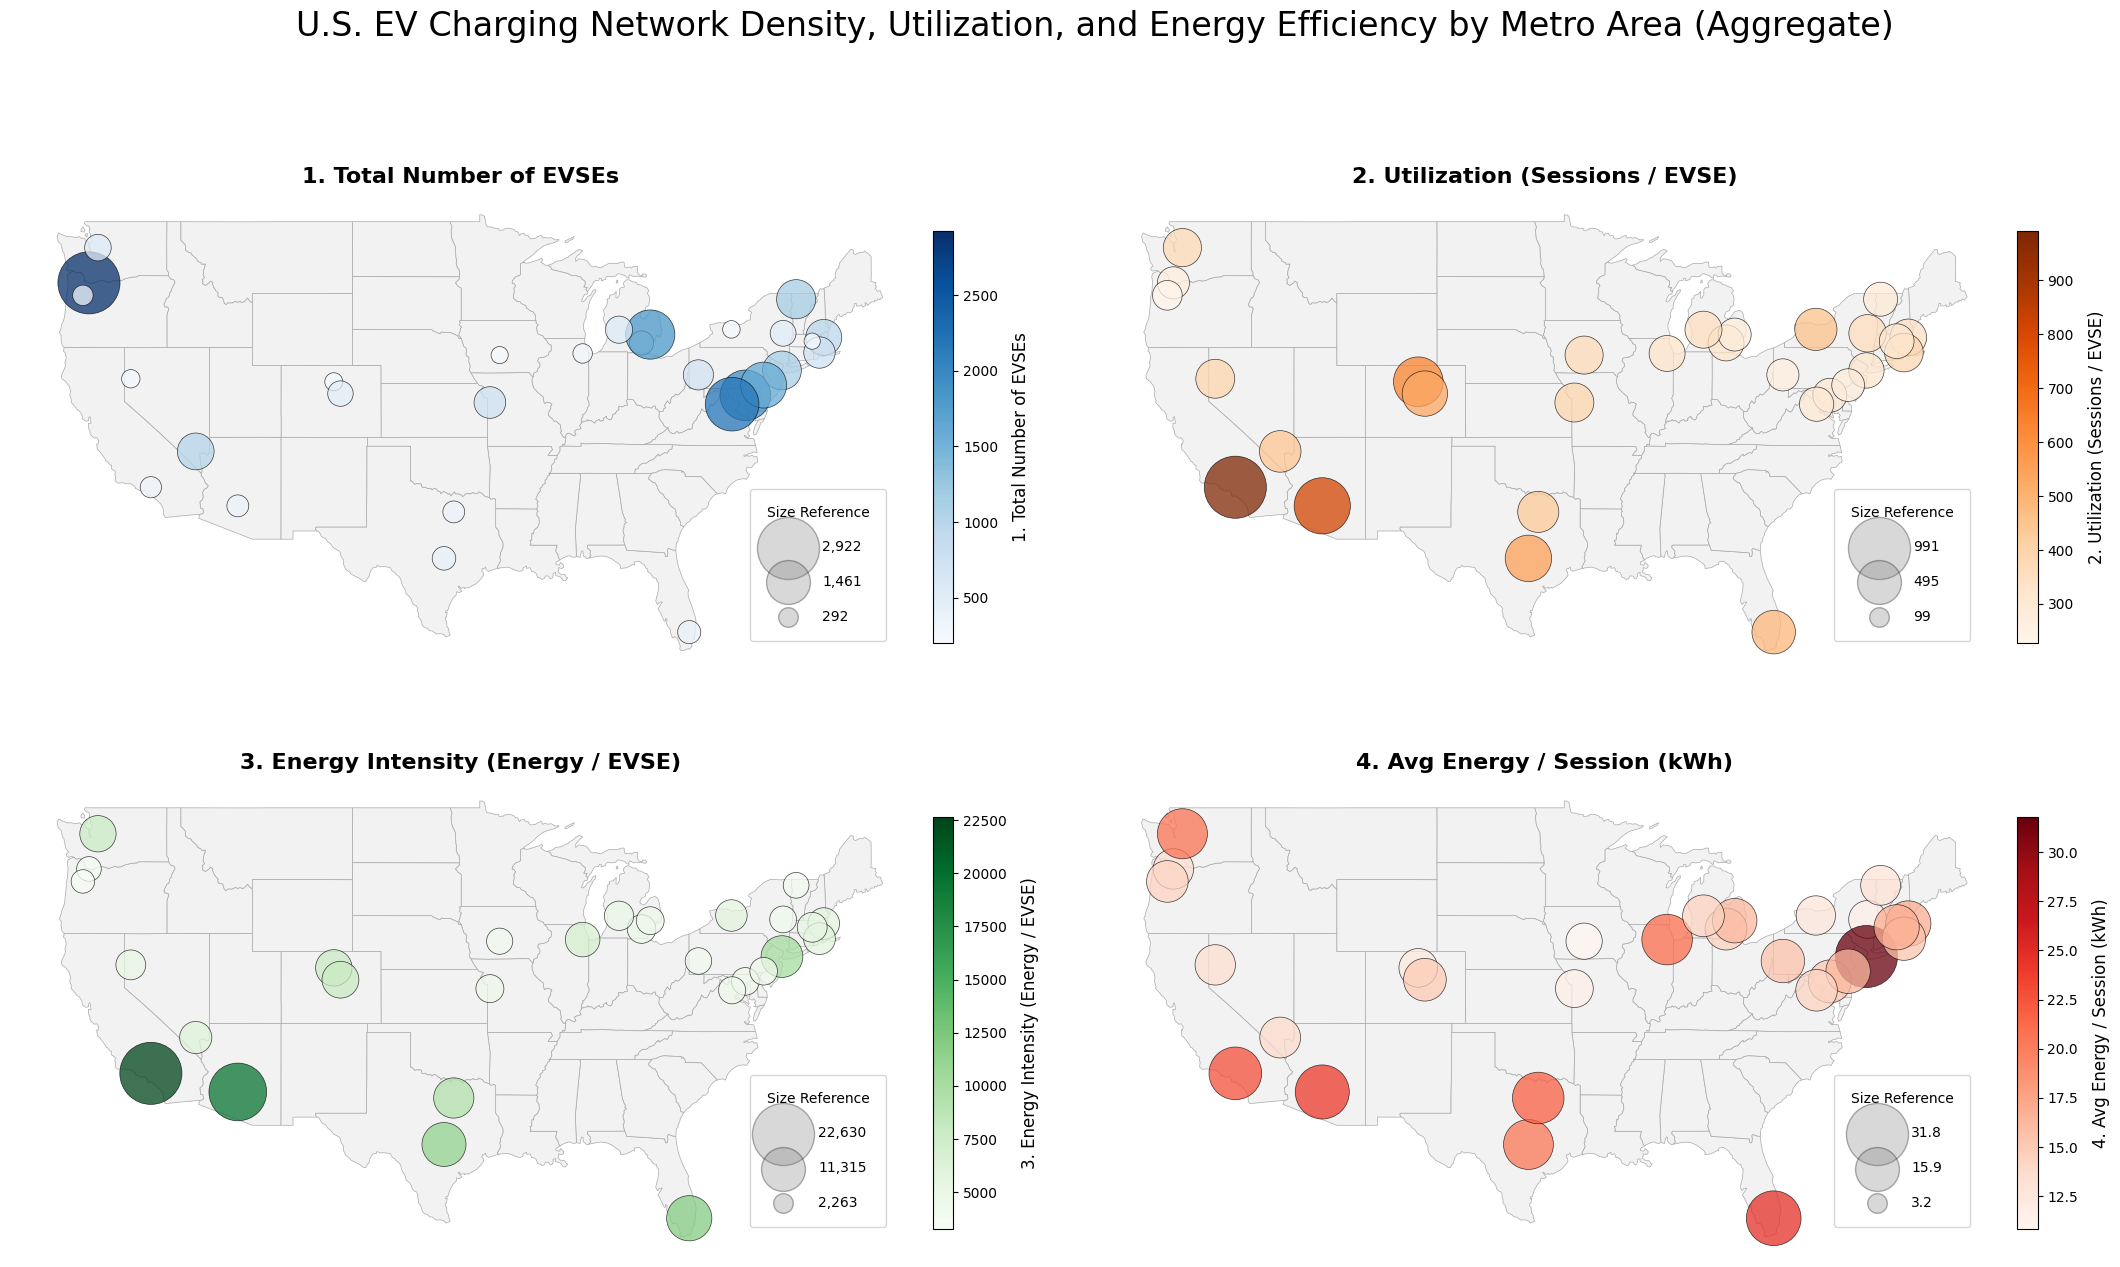

In [47]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

# -----------------------------------------------------------------------------
# 1. AGGREGATE THE DATA (Already including total energy and num_sessions)
# -----------------------------------------------------------------------------
metro_stats = allMerged_df.groupby("metro_area").agg(
    num_evse            = ("evse_id",         "nunique"), 
    num_sessions        = ("session_id",      "count"),
    total_energy_kwh    = ("energy_kwh",      "sum")
).reset_index()

# -----------------------------------------------------------------------------
# 2. CLEAN KEYS, MANUALLY MAP, AND MERGE LAT/LNG
# -----------------------------------------------------------------------------
def clean_key(name):
    return (name.replace(" Metro Area", "").replace(" metro area", "")
            .replace(" MSA", "").strip().lower())

metro_stats["metro_key"] = metro_stats["metro_area"].apply(clean_key)
metro_ref["metro_key"]   = metro_ref["metro_full"].apply(clean_key)

metro_ref_dedup = metro_ref[["metro_key", "lat", "lng"]].drop_duplicates("metro_key")

manual_map = {
    "austin-round rock-georgetown, tx":            "austin-round rock-san marcos, tx",
    "chicago-naperville-elgin, il-in-wi":          "chicago-naperville-elgin, il-in",
    "denver-aurora-lakewood, co":                  "denver-aurora-centennial, co",
    "grand rapids-kentwood, mi":                   "grand rapids-wyoming-kentwood, mi",
    "las vegas-henderson-paradise, nv":            "las vegas-henderson-north las vegas, nv",
    "miami-fort lauderdale-pompano beach, fl":     "miami-fort lauderdale-west palm beach, fl",
    "new york-newark-jersey city, ny-nj-pa":       "new york-newark-jersey city, ny-nj",
    "worcester, ma-ct":                            "worcester, ma",
}

metro_stats["metro_key_matched"] = metro_stats["metro_key"].apply(lambda k: manual_map.get(k, k))

merged = metro_stats.merge(
    metro_ref_dedup.rename(columns={"metro_key": "metro_key_matched"}),
    on="metro_key_matched",
    how="left"
)

# -----------------------------------------------------------------------------
# 3. CALCULATE NEW METRICS (Now all four!)
# -----------------------------------------------------------------------------
# Prevent division by zero
merged['num_evse'] = merged['num_evse'].replace(0, np.nan)
merged['num_sessions'] = merged['num_sessions'].replace(0, np.nan)

# Metric 2: Utilization (Sessions / EVSE)
merged['sessions_per_evse'] = merged['num_sessions'] / merged['num_evse']

# Metric 3: Energy Intensity (Energy / EVSE)
merged['energy_per_evse'] = merged['total_energy_kwh'] / merged['num_evse']

# Metric 4: New! Avg Energy per Session
merged['avg_energy_per_session'] = merged['total_energy_kwh'] / merged['num_sessions']

# Fill NaNs with 0
merged = merged.fillna({'sessions_per_evse': 0, 'energy_per_evse': 0, 'avg_energy_per_session': 0})

# -----------------------------------------------------------------------------
# 4. CONVERT TO GEODATAFRAME & LOAD US MAP
# -----------------------------------------------------------------------------
gdf_metros = gpd.GeoDataFrame(
    merged, 
    geometry=gpd.points_from_xy(merged.lng, merged.lat),
    crs="EPSG:4326"
)

# Load Continental US States map
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
usa = gpd.read_file(url)
usa = usa[~usa.name.isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# -----------------------------------------------------------------------------
# 5. PLOT THE BALANCED 2x2 GRID (Now complete!)
# -----------------------------------------------------------------------------
# Define the 4 metrics to plot (Column, Title, Colormap)
metrics_to_plot = [
    ('num_evse', '1. Total Number of EVSEs', 'Blues'),           
    ('sessions_per_evse', '2. Utilization (Sessions / EVSE)', 'Oranges'),    
    ('energy_per_evse', '3. Energy Intensity (Energy / EVSE)', 'Greens'),
    ('avg_energy_per_session', '4. Avg Energy / Session (kWh)', 'Reds') # Kontrasting Red Cmap
]

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten() 

# Base maximum bubble size (adjust this as needed)
max_bubble_size = 2000

for i, (col, title, cmap) in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # 1. Plot Continental US Base Map
    usa.plot(ax=ax, color='#f2f2f2', edgecolor='darkgray', linewidth=0.5)
    
    # 2. Set dynamic continuous color scale (Normalize between min and max)
    col_min = merged[col].min()
    col_max = merged[col].max()
    norm = Normalize(vmin=col_min, vmax=col_max)
    
    # 3. Calculate dynamic bubble sizes
    # Normalized so the largest metro for each map is exactly 'max_bubble_size'
    bubble_sizes = (merged[col] / col_max) * max_bubble_size
    
    # 4. Plot the Bubbles (Continuous color, continuous size)
    scatter = ax.scatter(
        merged.lng, merged.lat,
        s=bubble_sizes,
        c=merged[col],     # Value drives the continuous color
        cmap=cmap,         # Apply the colormap
        norm=norm,         # Apply normalization
        alpha=0.75,
        edgecolors='black',
        linewidth=0.5,
        zorder=3
    )
    
    # 5. Add Continuous Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # Required for matplotlib 3.1+
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02, aspect=20)
    cbar.set_label(title, fontsize=12, labelpad=10)
    
    # 6. Add Size Legend (Size Reference)
    # We create 3 reference handles (Max, 50%, and 10%) so the viewer understands scale
    legend_values = [col_max, col_max * 0.5, col_max * 0.1]
    for val in legend_values:
        size = (val / col_max) * max_bubble_size
        label_str = f'{val:,.1f}' if 'evse' not in col else f'{int(val):,}'
        
        # Plot invisible gray handles just for the legend
        ax.scatter([], [], c='gray', alpha=0.3, s=size,
                   label=label_str, edgecolors='black')
                   
    ax.legend(title="Size Reference", loc='lower right', bbox_to_anchor=(0.98, 0.05),
              labelspacing=1.5, borderpad=1.2, handletextpad=1.5, scatterpoints=1)
    
    # 7. Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim([-128, -65])
    ax.set_ylim([24, 50])
    ax.axis('off')

# Add a main title to the entire figure
fig.suptitle("U.S. EV Charging Network Density, Utilization, and Energy Efficiency by Metro Area (Aggregate)", fontsize=24, y=0.98)

plt.tight_layout()
# Adjust top padding so the main title doesn't overlap the subplots
plt.subplots_adjust(top=0.92) 
plt.show()

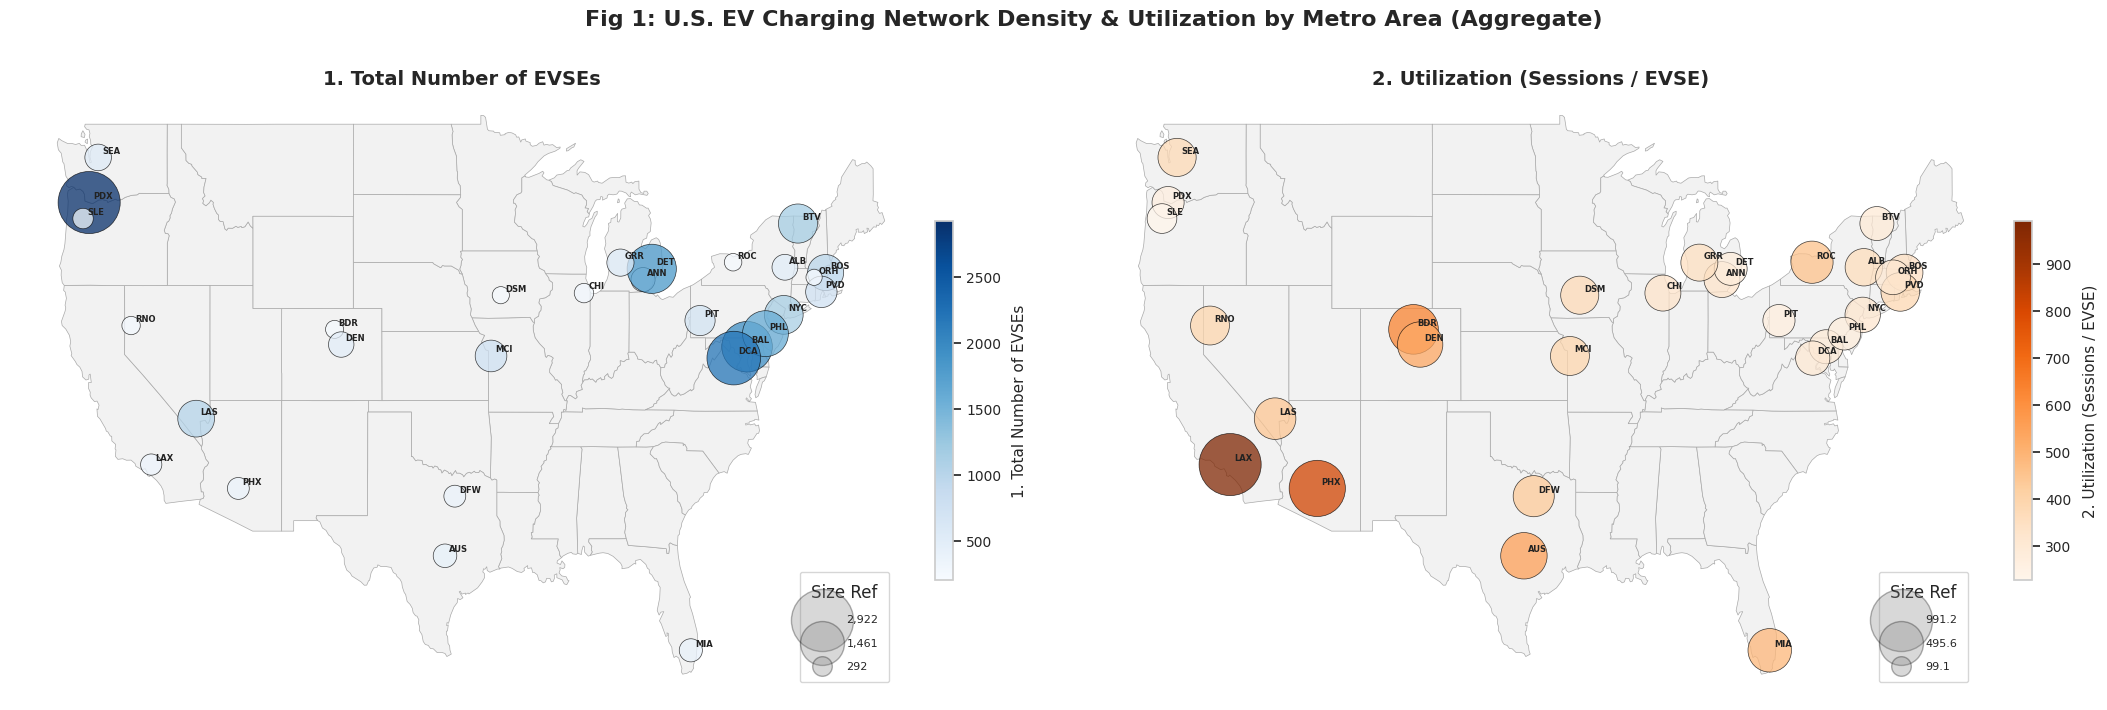

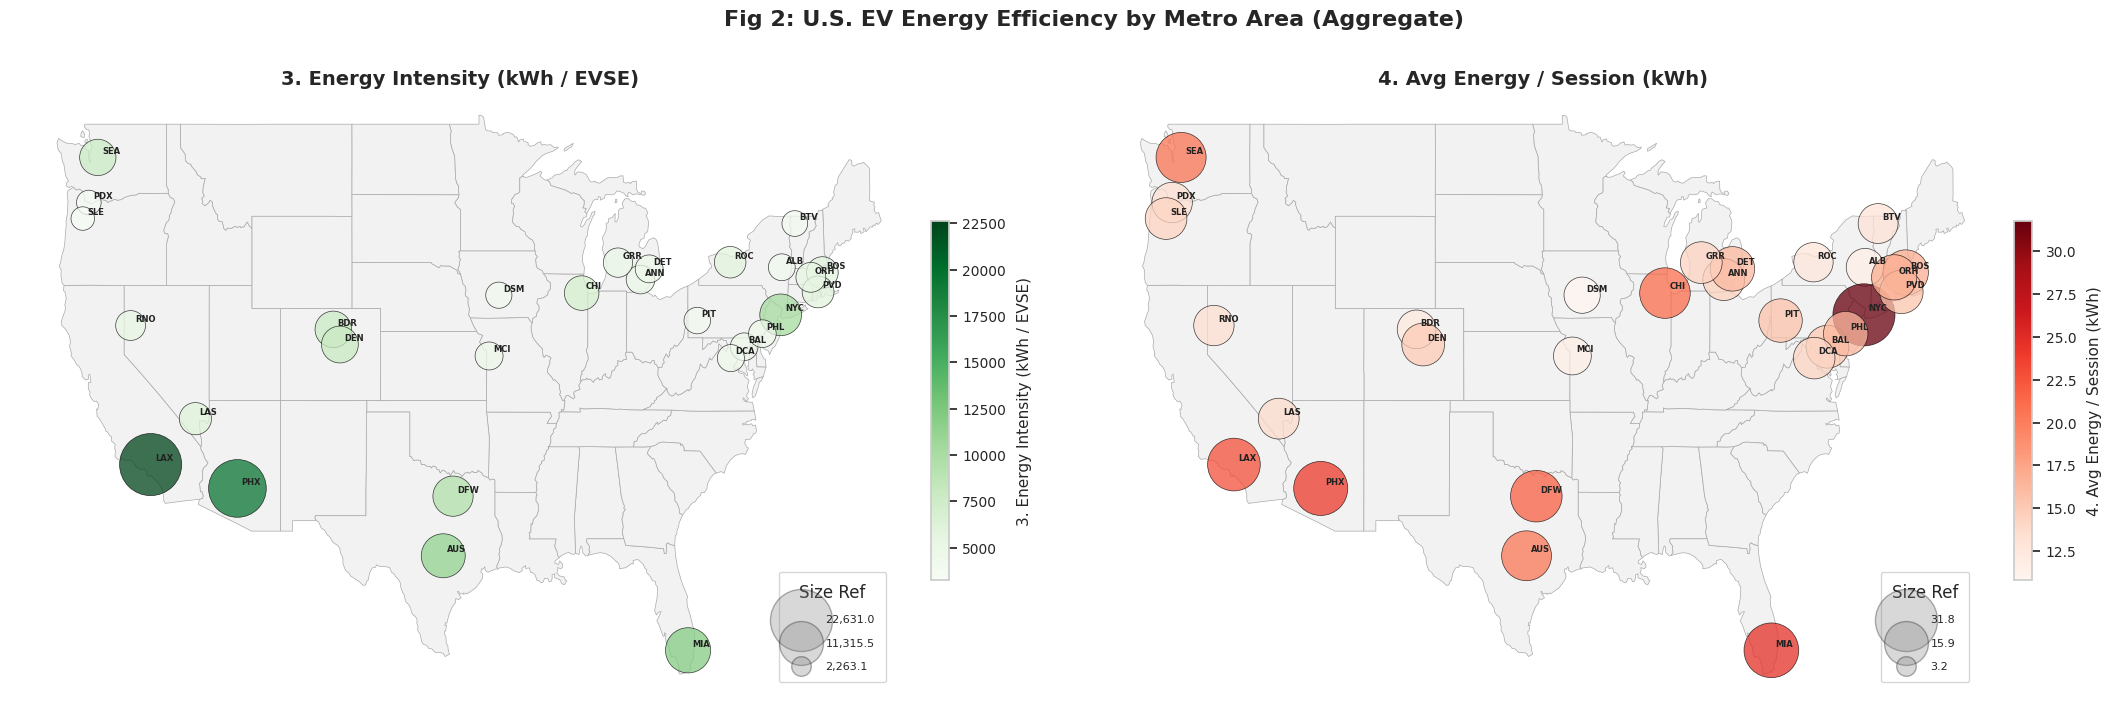

In [53]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

# -----------------------------------------------------------------------------
# METRO ABBREVIATIONS
# -----------------------------------------------------------------------------
metro_abbrev = {
    "Albany-Schenectady-Troy, NY Metro Area":                        "ALB",
    "Ann Arbor, MI Metro Area":                                      "ANN",
    "Austin-Round Rock-Georgetown, TX Metro Area":                   "AUS",
    "Baltimore-Columbia-Towson, MD Metro Area":                      "BAL",
    "Boston-Cambridge-Newton, MA-NH Metro Area":                     "BOS",
    "Boulder, CO Metro Area":                                        "BDR",
    "Burlington-South Burlington, VT Metro Area":                    "BTV",
    "Chicago-Naperville-Elgin, IL-IN-WI Metro Area":                 "CHI",
    "Dallas-Fort Worth-Arlington, TX Metro Area":                    "DFW",
    "Denver-Aurora-Lakewood, CO Metro Area":                         "DEN",
    "Des Moines-West Des Moines, IA Metro Area":                     "DSM",
    "Detroit-Warren-Dearborn, MI Metro Area":                        "DET",
    "Grand Rapids-Kentwood, MI Metro Area":                          "GRR",
    "Kansas City, MO-KS Metro Area":                                 "MCI",
    "Las Vegas-Henderson-Paradise, NV Metro Area":                   "LAS",
    "Los Angeles-Long Beach-Anaheim, CA Metro Area":                 "LAX",
    "Miami-Fort Lauderdale-Pompano Beach, FL Metro Area":            "MIA",
    "New York-Newark-Jersey City, NY-NJ-PA Metro Area":              "NYC",
    "Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area":        "PHL",
    "Phoenix-Mesa-Chandler, AZ Metro Area":                          "PHX",
    "Pittsburgh, PA Metro Area":                                     "PIT",
    "Portland-Vancouver-Hillsboro, OR-WA Metro Area":                "PDX",
    "Providence-Warwick, RI-MA Metro Area":                          "PVD",
    "Reno, NV Metro Area":                                           "RNO",
    "Rochester, NY Metro Area":                                      "ROC",
    "Salem, OR Metro Area":                                          "SLE",
    "Seattle-Tacoma-Bellevue, WA Metro Area":                        "SEA",
    "Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area":       "DCA",
    "Worcester, MA-CT Metro Area":                                   "ORH",
}

merged["abbrev"] = merged["metro_area"].map(metro_abbrev).fillna("")

# -----------------------------------------------------------------------------
# LOAD US MAP
# -----------------------------------------------------------------------------
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
usa = gpd.read_file(url)
usa = usa[~usa.name.isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# -----------------------------------------------------------------------------
# HELPER: draw one bubble map panel
# -----------------------------------------------------------------------------
def draw_panel(ax, col, title, cmap, max_bubble_size=2000):
    col_min = merged[col].min()
    col_max = merged[col].max()
    norm    = Normalize(vmin=col_min, vmax=col_max)

    usa.plot(ax=ax, color='#f2f2f2', edgecolor='darkgray', linewidth=0.5)
    ax.set_aspect("auto")

    bubble_sizes = (merged[col] / col_max) * max_bubble_size

    scatter = ax.scatter(
        merged.lng, merged.lat,
        s=bubble_sizes,
        c=merged[col],
        cmap=cmap,
        norm=norm,
        alpha=0.75,
        edgecolors='black',
        linewidth=0.5,
        zorder=3
    )

    # Metro abbreviation labels
    for _, row in merged.iterrows():
        ax.annotate(
            row["abbrev"],
            xy=(row["lng"], row["lat"]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=6,
            fontweight="bold",
            color="#222222",
            zorder=4
        )

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02, aspect=20)
    cbar.set_label(title, fontsize=11, labelpad=8)

    # Size legend
    for val in [col_max, col_max * 0.5, col_max * 0.1]:
        size      = (val / col_max) * max_bubble_size
        label_str = f'{int(val):,}' if ('evse' in col and 'per' not in col) else f'{val:,.1f}'
        ax.scatter([], [], c='gray', alpha=0.3, s=size,
                   label=label_str, edgecolors='black')

    ax.legend(title="Size Ref", loc='lower right',
              bbox_to_anchor=(0.98, 0.02),
              labelspacing=1.2, borderpad=1.0,
              handletextpad=1.2, scatterpoints=1, fontsize=8)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlim([-128, -65])
    ax.set_ylim([24, 50])
    ax.axis('off')


In [54]:
import math

def round_to_nice(val):
    """Round to 1 significant figure for clean legend labels."""
    if val == 0:
        return 0
    magnitude = 10 ** math.floor(math.log10(abs(val)))
    return round(val / magnitude) * magnitude

def draw_panel(ax, col, title, cmap, max_bubble_size=2000):
    col_min = merged[col].min()
    col_max = merged[col].max()
    norm    = Normalize(vmin=col_min, vmax=col_max)

    usa.plot(ax=ax, color='#f2f2f2', edgecolor='darkgray', linewidth=0.5)
    ax.set_aspect("auto")

    bubble_sizes = (merged[col] / col_max) * max_bubble_size

    ax.scatter(
        merged.lng, merged.lat,
        s=bubble_sizes,
        c=merged[col],
        cmap=cmap,
        norm=norm,
        alpha=0.75,
        edgecolors='black',
        linewidth=0.5,
        zorder=3
    )

    # Metro abbreviation labels
    for _, row in merged.iterrows():
        ax.annotate(
            row["abbrev"],
            xy=(row["lng"], row["lat"]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=6,
            fontweight="bold",
            color="#222222",
            zorder=4
        )

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02, aspect=20)
    cbar.set_label(title, fontsize=11, labelpad=8)

    # ── Size legend with rounded nice numbers ─────────────────────────────────
    raw_values    = [col_max, col_max * 0.5, col_max * 0.1]
    legend_values = [round_to_nice(v) for v in raw_values]

    for val in legend_values:
        size      = (val / col_max) * max_bubble_size
        label_str = f'{int(val):,}' if val >= 10 else f'{val:.1f}'
        ax.scatter([], [], c='gray', alpha=0.3, s=size,
                   label=label_str, edgecolors='black')

    ax.legend(title="Size Ref", loc='lower right',
              bbox_to_anchor=(0.98, 0.02),
              labelspacing=1.2, borderpad=1.0,
              handletextpad=1.2, scatterpoints=1, fontsize=8)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlim([-128, -65])
    ax.set_ylim([24, 50])
    ax.axis('off')

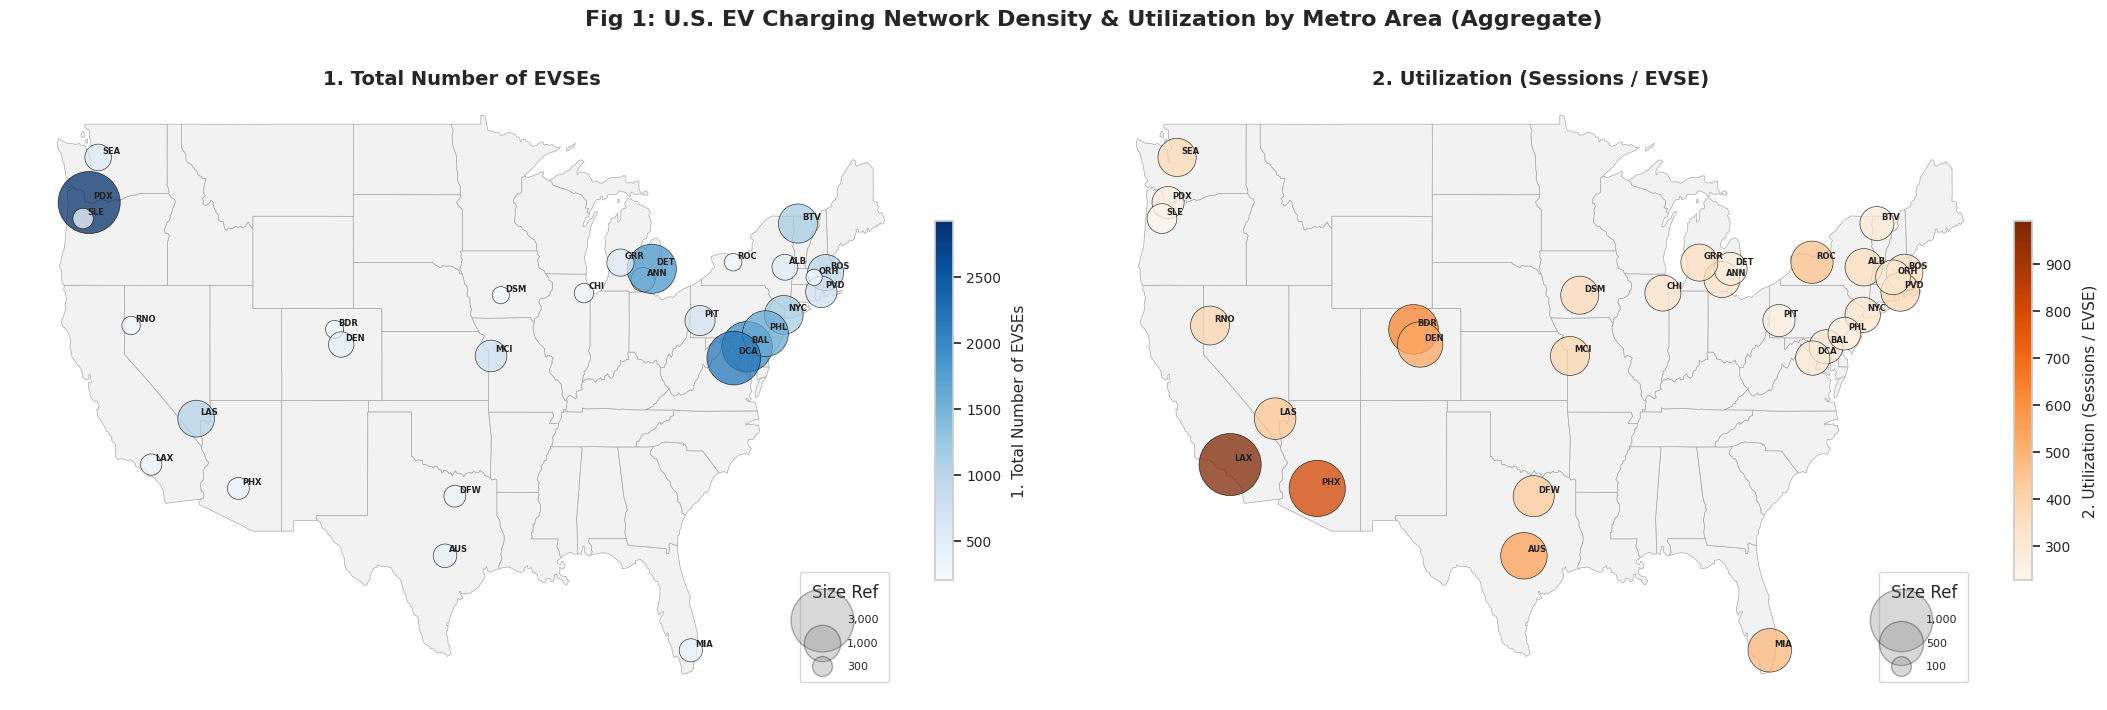

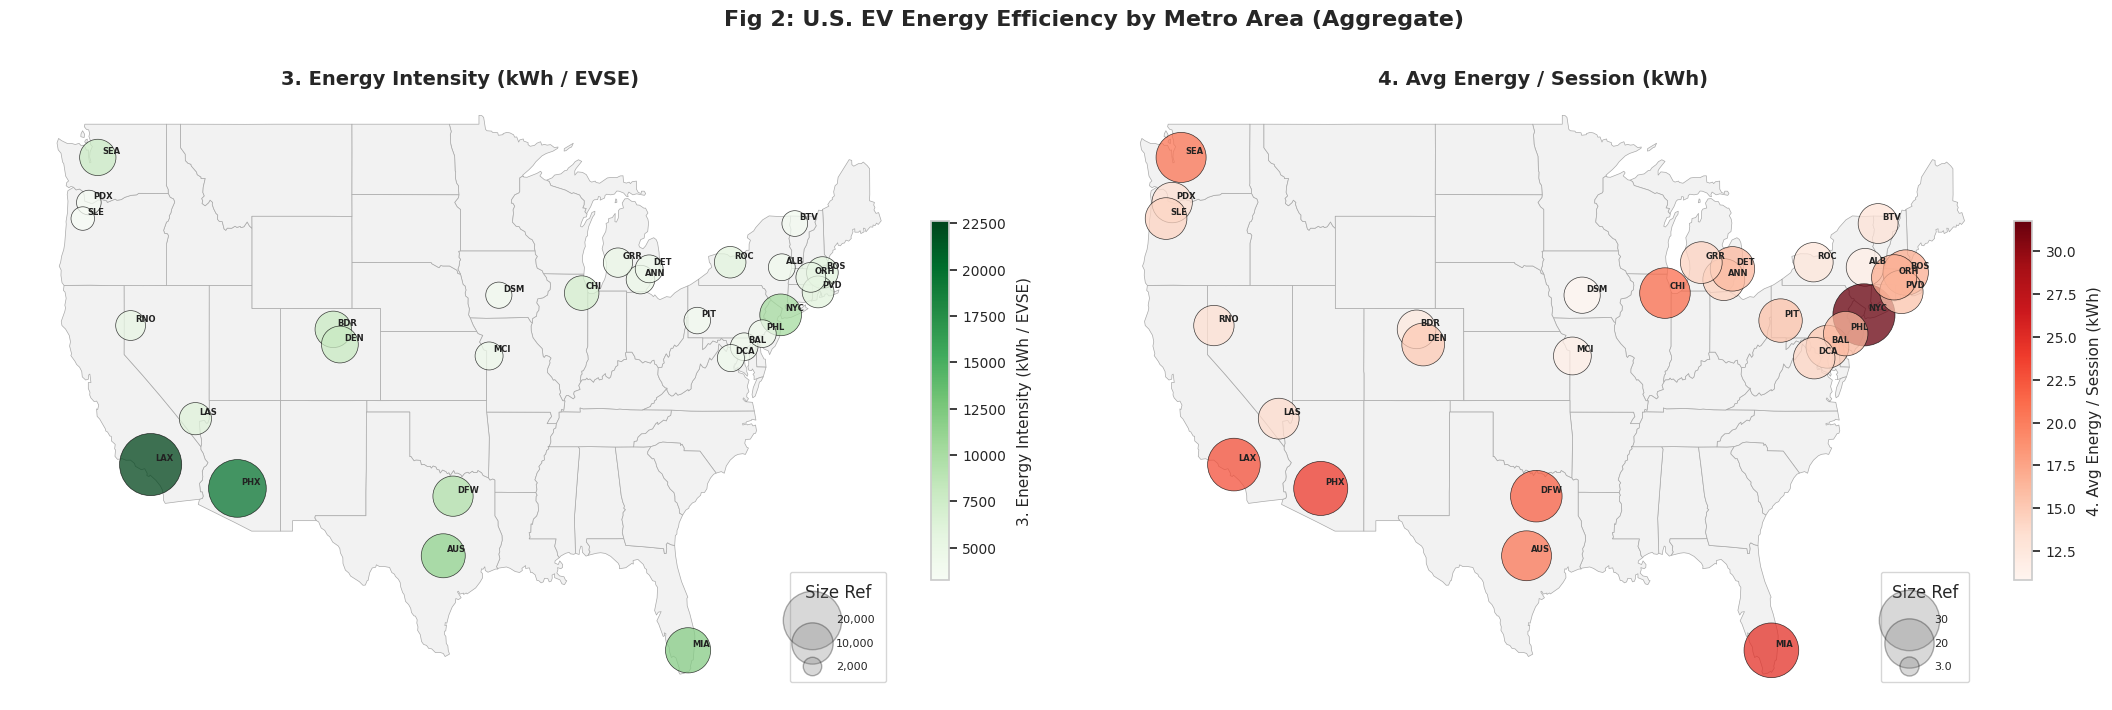

In [55]:

# =============================================================================
# FIGURE 1: Density & Utilization
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle("Fig 1: U.S. EV Charging Network Density & Utilization by Metro Area (Aggregate)",
             fontsize=16, fontweight='bold', y=1.01)

draw_panel(axes[0], 'num_evse',          '1. Total Number of EVSEs',          'Blues')
draw_panel(axes[1], 'sessions_per_evse', '2. Utilization (Sessions / EVSE)',  'Oranges')

plt.tight_layout()
plt.savefig("fig1_density_utilization.png", dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 2: Energy Efficiency
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle("Fig 2: U.S. EV Energy Efficiency by Metro Area (Aggregate)",
             fontsize=16, fontweight='bold', y=1.01)

draw_panel(axes[0], 'energy_per_evse',       '3. Energy Intensity (kWh / EVSE)',   'Greens')
draw_panel(axes[1], 'avg_energy_per_session','4. Avg Energy / Session (kWh)',       'Reds')

plt.tight_layout()
plt.savefig("fig2_energy_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()